# Incomplete-Fix Case Set — PILOT Correlation, Bias & ML-Feasibility Study

**Companion notebook to `incomplete_fixes_descriptive_analysis.ipynb`.**

**This is a pilot / go-no-go feasibility study, not a model-training
notebook.** The current dataset (n=52 rows / 51 cases) is expected to grow
to roughly **4-5x its current size (~200-260 cases)** once data
construction is complete. The question this notebook answers is not "how
good is the model" — at n=52 no model built here should be trusted for
production use — but:

> **Is there enough correlation/bias/signal already visible at n=52 to
> justify investing in building out the full dataset — and, separately, is
> the detection task even well-posed?**

Two detection goals were named, and they are *not* symmetric:

- **Subtype detection** (e.g. "is this Structural Duplication?", given a
  fix already confirmed incomplete) — a normal, well-posed supervised
  classification problem. Every row has a positive label for exactly one
  of 13 subtypes, so ordinary multiclass/binary classification applies.
- **General incomplete-fix detection** ("is this fix incomplete, yes/no",
  evaluated on *any* fix, not just ones already known to be incomplete) —
  **this one has no clean negative class, and it is important to be
  precise about why**: it is not simply that we haven't *collected*
  negative examples yet. A "complete" fix cannot be positively defined —
  you can only ever say a fix has *not yet* been shown incomplete, not
  that it never will be. That makes this a fundamentally different, harder
  problem than ordinary binary classification, no matter how much the
  dataset grows. Section 10-11 below work through what *is* still doable
  (risk-scoring, one-class/anomaly framing, PU-learning) versus what
  a bigger dataset can and cannot fix.

**Notebook contents:**
1. Re-derivation of the enriched dataframe (self-contained).
2. Categorical association tests (chi-square / Cramer's V).
3. Numeric correlation matrix + group-difference (Kruskal-Wallis) tests.
4. Class-balance / sample-size feasibility analysis at current n.
5. Confounding / leakage check (product-identity vs. bypass-mechanism text).
6. Baseline LOOCV ML-feasibility experiments (subtype / parent / binary).
7. Most-distinctive terms per parent group.
8. **Why "any incomplete fix, yes/no" has no true negative class — and
   what to do instead** (risk-scoring / one-class / PU-learning framing,
   with a small proof-of-concept).
9. **Power analysis: what would 4-5x more data actually buy us?** —
   projecting current effect sizes and confidence intervals forward to the
   planned dataset size, to give a concrete, numeric go/no-go signal.
10. Pilot-study conclusion and a stratified (not just proportional) data-
    collection recommendation for the next build-out pass.

**Inputs expected in the same directory:** `incomplete_fixes_2.csv`.

## 0. Setup

In [6]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
#matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency, kruskal, spearmanr

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import LeaveOneOut, StratifiedKFold, cross_val_predict
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                              confusion_matrix, roc_auc_score)
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 160
plt.rcParams["axes.titleweight"] = "bold"

CSV_PATH = "incomplete_fixes_2.csv"
OUTDIR = "figures_bias"
os.makedirs(OUTDIR, exist_ok=True)

def savefig(fig, name):
    path = os.path.join(OUTDIR, name)
    fig.tight_layout()
    fig.savefig(path, dpi=160, bbox_inches="tight")
    print("saved:", path)

RANDOM_STATE = 42

## 1. Taxonomy & parsers (identical to the descriptive notebook, reproduced here so this notebook is self-contained)

In [7]:
"""
Shared incomplete-fix subtype taxonomy for the 52-row / 51-case dataset
(CASE-01 .. CASE-51, plus sibling CASE-03B).

Every case gets exactly ONE primary subtype, assigned by reading its
root_cause_category + bypass_mechanism_root_cause + classification_note
text. Cases 1-18 retain the classification from the first-batch analysis;
cases 19-51 are newly classified here using the same methodology.
"""

# ---------------------------------------------------------------------------
# Parent groups (6) -- coarse-grained families the fine subtypes roll up into
# ---------------------------------------------------------------------------
PARENT_GROUP_ORDER = [
    "Structural Duplication",
    "Logic / Invariant Error",
    "Call-Chain / Scope",
    "Dual-Operation Symmetry",
    "Trust-Boundary / Delegation Gap",
    "Process / Supply-Chain Failure",
]

PARENT_GROUP_DEFINITIONS = {
    "Structural Duplication":
        "The fix needed to be applied at N structurally similar sites "
        "(files / code trees / call sites / list members / branches) and "
        "was only applied at M < N of them.",
    "Logic / Invariant Error":
        "A guard/check exists and runs, but its condition, threshold, "
        "type width, or the quantity it protects does not actually match "
        "the real attack/overflow condition -- not a coverage gap.",
    "Call-Chain / Scope":
        "The exploitable defect lives at a different point in the call "
        "chain (an upstream caller/validator, downstream consumer, or a "
        "producer/consumer counterpart) than where the patch landed.",
    "Dual-Operation Symmetry":
        "Two mirror-image operations exist (open/close, alloc/fill, "
        "read/write, create/finalize); the fix hardens one side and "
        "leaves its structural mirror untouched.",
    "Trust-Boundary / Delegation Gap":
        "The fix never examined WHO/WHAT could invoke the protected path, "
        "or silently delegated a security-relevant invariant to code "
        "(often a third-party library) that was never itself audited.",
    "Process / Supply-Chain Failure":
        "The gap is not a code-logic defect at all -- it is a packaging, "
        "release, or backport-assertion failure (a fix was claimed to be "
        "shipped/applied but was not).",
}

PARENT_COLORS = {
    "Structural Duplication":          "#2E5EAA",
    "Logic / Invariant Error":         "#4E9B4E",
    "Call-Chain / Scope":              "#E07B39",
    "Dual-Operation Symmetry":         "#B4436C",
    "Trust-Boundary / Delegation Gap": "#8A5A83",
    "Process / Supply-Chain Failure":  "#9A9A3D",
}

# ---------------------------------------------------------------------------
# Fine-grained subtypes (13) -- definitions
# ---------------------------------------------------------------------------
SUBTYPE_DEFINITIONS = {
    "Parallel implementation miss":
        "The same logic is duplicated across multiple files, code trees, "
        "binaries, or lookup-path implementations (e.g. SDL2 vs SDL3, "
        "generic vs SIMD, Web vs Component server); the fix is applied to "
        "only a subset of the duplicates.",
    "Security logic implemented but not applied":
        "A reusable protective primitive (helper function, macro, wrapper) "
        "was correctly written and correctly used at most call sites, but "
        "was never wired into one additional site that needed it.",
    "Field/parameter-family miss":
        "The fix enumerates a family of fields/parameters/members/option-"
        "spellings/reference-holder-classes to protect but omits one "
        "member of that family.",
    "Backport/distro re-derivation miss":
        "A downstream distro, LTS branch, or older codebase's fix had to "
        "be manually re-implemented (not cherry-picked verbatim) against "
        "differently-structured code, and the re-derivation introduced a "
        "gap the upstream, verbatim version does not have.",
    "Scope-of-audit miss":
        "The original fix was produced by an audit (manual, grep-based, or "
        "reproducer-driven) that covered the exact reported call site / "
        "branch / function but never widened to structurally similar "
        "sibling call sites, branches, or functions.",
    "Wrong invariant / off-by-construction":
        "A guard/bound/algorithm was added and IS reached, but its "
        "condition, threshold, sentinel value, or design does not actually "
        "match the real overflow/bypass condition (miscalibration or "
        "algorithmic edge case, not a coverage gap).",
    "Platform/environment-dependent assumption":
        "The fix's correctness silently depends on a platform-specific "
        "property (integer width, architecture, build configuration) that "
        "does not hold on every supported platform.",
    "Incidental invariant loss (refactor side-effect)":
        "A refactor that correctly fixes the targeted defect incidentally "
        "removes an unrelated side effect that other code silently relied "
        "on, opening a new (different-class) gap in the same commit.",
    "Upstream/downstream caller miss":
        "The exploitable defect actually lives in a different function of "
        "the call chain (an upstream validator/caller, a downstream "
        "consumer, or the producer/reader counterpart of a build/read "
        "pair) than the function that was patched.",
    "Symmetric/dual-operation miss":
        "Two mirror-image operations exist (open/close, alloc/fill, "
        "read/write, create/finalize, '('/')'); the fix hardens one side "
        "and leaves its structural mirror untouched.",
    "Threat-model too narrow (who/what unconsidered)":
        "The fix correctly restricts WHICH resource/path may be used, but "
        "never asks WHO may trigger the operation or WHAT the operation "
        "itself can do as a side effect -- the exploited primitive sat "
        "entirely outside the original threat model.",
    "Delegated/unaudited external-dependency miss":
        "A security invariant (e.g. constant-time behaviour) is silently "
        "delegated to a third-party library or component whose internals "
        "were never audited and are outside the fixer's control.",
    "Packaging/backport assertion failure":
        "There is no source-code defect distinct from the original "
        "vulnerability; an advisory/package asserted a fix was shipped "
        "when the shipped binary still contained the original, unpatched "
        "code.",
}

# subtype -> parent group
SUBTYPE_PARENT = {
    "Parallel implementation miss":                        "Structural Duplication",
    "Security logic implemented but not applied":           "Structural Duplication",
    "Field/parameter-family miss":                          "Structural Duplication",
    "Backport/distro re-derivation miss":                   "Structural Duplication",
    "Scope-of-audit miss":                                  "Structural Duplication",
    "Wrong invariant / off-by-construction":                "Logic / Invariant Error",
    "Platform/environment-dependent assumption":            "Logic / Invariant Error",
    "Incidental invariant loss (refactor side-effect)":     "Logic / Invariant Error",
    "Upstream/downstream caller miss":                      "Call-Chain / Scope",
    "Symmetric/dual-operation miss":                        "Dual-Operation Symmetry",
    "Threat-model too narrow (who/what unconsidered)":      "Trust-Boundary / Delegation Gap",
    "Delegated/unaudited external-dependency miss":         "Trust-Boundary / Delegation Gap",
    "Packaging/backport assertion failure":                 "Process / Supply-Chain Failure",
}

# ---------------------------------------------------------------------------
# case_id -> fine subtype   (52 rows: CASE-01..CASE-51 + sibling CASE-03B)
# ---------------------------------------------------------------------------
SUBTYPE_MAP = {
    "CASE-01": "Symmetric/dual-operation miss",
    "CASE-02": "Symmetric/dual-operation miss",
    "CASE-03": "Scope-of-audit miss",
    "CASE-03B": "Security logic implemented but not applied",
    "CASE-04": "Parallel implementation miss",
    "CASE-05": "Upstream/downstream caller miss",
    "CASE-06": "Parallel implementation miss",
    "CASE-07": "Wrong invariant / off-by-construction",
    "CASE-08": "Field/parameter-family miss",
    "CASE-09": "Symmetric/dual-operation miss",
    "CASE-10": "Parallel implementation miss",
    "CASE-11": "Upstream/downstream caller miss",
    "CASE-12": "Security logic implemented but not applied",
    "CASE-13": "Wrong invariant / off-by-construction",
    "CASE-14": "Wrong invariant / off-by-construction",
    "CASE-15": "Upstream/downstream caller miss",
    "CASE-16": "Security logic implemented but not applied",
    "CASE-17": "Parallel implementation miss",
    "CASE-18": "Parallel implementation miss",
    "CASE-19": "Threat-model too narrow (who/what unconsidered)",
    "CASE-20": "Backport/distro re-derivation miss",
    "CASE-21": "Wrong invariant / off-by-construction",
    "CASE-22": "Upstream/downstream caller miss",
    "CASE-23": "Backport/distro re-derivation miss",
    "CASE-24": "Wrong invariant / off-by-construction",
    "CASE-25": "Wrong invariant / off-by-construction",
    "CASE-26": "Symmetric/dual-operation miss",
    "CASE-27": "Backport/distro re-derivation miss",
    "CASE-28": "Scope-of-audit miss",
    "CASE-29": "Scope-of-audit miss",
    "CASE-30": "Platform/environment-dependent assumption",
    "CASE-31": "Field/parameter-family miss",
    "CASE-32": "Field/parameter-family miss",
    "CASE-33": "Field/parameter-family miss",
    "CASE-34": "Wrong invariant / off-by-construction",
    "CASE-35": "Scope-of-audit miss",
    "CASE-36": "Wrong invariant / off-by-construction",
    "CASE-37": "Upstream/downstream caller miss",
    "CASE-38": "Backport/distro re-derivation miss",
    "CASE-39": "Field/parameter-family miss",
    "CASE-40": "Scope-of-audit miss",
    "CASE-41": "Upstream/downstream caller miss",
    "CASE-42": "Upstream/downstream caller miss",
    "CASE-43": "Wrong invariant / off-by-construction",
    "CASE-44": "Scope-of-audit miss",
    "CASE-45": "Field/parameter-family miss",
    "CASE-46": "Delegated/unaudited external-dependency miss",
    "CASE-47": "Delegated/unaudited external-dependency miss",
    "CASE-48": "Packaging/backport assertion failure",
    "CASE-49": "Security logic implemented but not applied",
    "CASE-50": "Incidental invariant loss (refactor side-effect)",
    "CASE-51": "Field/parameter-family miss",
}


def get_parent(case_id):
    return SUBTYPE_PARENT[SUBTYPE_MAP[case_id]]


def classify_row(case_id):
    sub = SUBTYPE_MAP[case_id]
    return sub, SUBTYPE_PARENT[sub], SUBTYPE_DEFINITIONS[sub]

In [8]:
"""
Free-text field parsers shared by both notebooks. Every parser is
best-effort/heuristic (the source fields are analyst prose, not
structured data) and documented as such in the notebooks.
"""
import re
import numpy as np

# --------------------------------------------------------------------
# CWE / CVSS
# --------------------------------------------------------------------
def extract_cwe_ids(text):
    if not isinstance(text, str):
        return []
    return sorted(set(re.findall(r"CWE-(\d+)", text)))


def extract_cvss_scores(text):
    """All plausible 0.0-10.0 CVSS base scores mentioned in a free-text field."""
    if not isinstance(text, str):
        return []
    out = []
    for m in re.findall(r"\b(\d{1,2}\.\d)\b", text):
        v = float(m)
        if 0.0 <= v <= 10.0:
            out.append(v)
    return out


def first_cvss(text):
    s = extract_cvss_scores(text)
    return s[0] if s else np.nan


def max_cvss(text):
    s = extract_cvss_scores(text)
    return max(s) if s else np.nan


def extract_severity_word(text):
    if not isinstance(text, str):
        return None
    for w in ["CRITICAL", "HIGH", "MEDIUM", "LOW", "NONE"]:
        if w in text.upper():
            return w.title()
    return None


# --------------------------------------------------------------------
# num_distinct_cve_ids_in_lineage  ("2", "3 (shared lineage w/ CASE-03B)")
# --------------------------------------------------------------------
def parse_num_cves(text):
    if not isinstance(text, str):
        return np.nan
    m = re.search(r"(\d+)", text)
    return int(m.group(1)) if m else np.nan


# --------------------------------------------------------------------
# Time gap between original fix and bypass discovery
# --------------------------------------------------------------------
GAP_ORDER = ["< 1 week", "1-4 weeks", "1-6 months", "6-24 months", "2+ years", "Unknown"]

def bucket_gap(text):
    if not isinstance(text, str) or not text.strip():
        return "Unknown"
    t = text.lower()
    if any(p in t for p in ["essentially immediate", "same release", "same commit", "days apart"]):
        pass  # fall through to day/week parsing below for precision
    m_days = re.search(r"(\d+)\s*day", t)
    m_weeks = re.search(r"(\d+)\s*week", t)
    m_months = re.search(r"~?\u2248?(\d+(?:\.\d+)?)\s*\+?\s*month", t)
    m_years = re.search(r"~?\u2248?(\d+(?:\.\d+)?)\s*\+?\s*year", t)
    if m_years:
        y = float(m_years.group(1))
        return "6-24 months" if y < 2 else "2+ years"
    if m_months:
        mo = float(m_months.group(1))
        if mo < 1:
            return "1-4 weeks"
        elif mo <= 6:
            return "1-6 months"
        else:
            return "6-24 months"
    if m_weeks:
        w = int(m_weeks.group(1))
        return "1-4 weeks" if w <= 4 else "1-6 months"
    if m_days:
        d = int(m_days.group(1))
        return "< 1 week" if d < 7 else "1-4 weeks"
    if "immediate" in t or "same release" in t or "same commit" in t or "days apart" in t:
        return "< 1 week"
    return "Unknown"


def gap_days_numeric(text):
    """Approximate numeric day count for correlation/regression use. NaN if unparseable."""
    if not isinstance(text, str) or not text.strip():
        return np.nan
    t = text.lower()
    m_years = re.search(r"~?\u2248?(\d+(?:\.\d+)?)\s*\+?\s*year", t)
    if m_years:
        return float(m_years.group(1)) * 365.25
    m_months = re.search(r"~?\u2248?(\d+(?:\.\d+)?)\s*\+?\s*month", t)
    if m_months:
        return float(m_months.group(1)) * 30.44
    m_weeks = re.search(r"(\d+)\s*week", t)
    if m_weeks:
        return float(m_weeks.group(1)) * 7
    m_days = re.search(r"(\d+)\s*day", t)
    if m_days:
        return float(m_days.group(1))
    if "immediate" in t or "same release" in t or "same commit" in t:
        return 1.0
    return np.nan


# --------------------------------------------------------------------
# Ecosystem / domain classification (heuristic, from product_component +
# source_file_path(s) + affected_language)
# --------------------------------------------------------------------
_ECOSYSTEM_RULES = [
    ("OS Kernel",                 [r"\blinux kernel\b", r"\bkernel\b", r"^net/", r"drivers/", r"fs/smb", r"net/sched", r"net/core"]),
    ("Hypervisor / Virtualization",[r"\bxen\b", r"\bqemu\b", r"hypervisor", r"virtio"]),
    ("Windowing / Display System", [r"x\.org", r"xserver", r"xwayland", r"\bxkb\b"]),
    ("Network Daemon / Protocol Server", [r"dovecot", r"openssh", r"ssh-agent", r"\bhttp server\b", r"apache http", r"ldap", r"389 directory", r"unbound", r"dns resolver", r"netfilter", r"ebtables", r"nftables"]),
    ("Browser / Web Client",       [r"brave browser", r"firefox", r"chrom"]),
    ("Language Runtime / Interpreter", [r"\bphp\b", r"redis", r"tensorflow"]),
    ("Media / Codec Library",      [r"libsndfile", r"gstreamer", r"wav demuxer", r"furnace", r"chiptune"]),
    ("Parsing / Data-format Library", [r"libexpat", r"editorconfig", r"pillow", r"tiff", r"bento4", r"mp4", r"binutils", r"bfd", r"rpm package"]),
    ("Archive / Compression Tool", [r"gnome-autoar", r"file-roller", r"zstandard", r"\bzstd\b"]),
    ("Embedded / IoT Stack",       [r"netx duo", r"threadx", r"azure rtos"]),
    ("Wireless / WPA Security",    [r"hostapd", r"wpa_supplicant"]),
    ("System Utility / Init",      [r"systemd", r"iputils", r"\bping\b", r"sysstat", r"conemu"]),
    ("VM / Container Management",  [r"multipass", r"dnf5daemon"]),
    ("HTTP Client Library",        [r"cpp-httplib"]),
    ("Backup / Ops Tool",          [r"percona xtrabackup"]),
    ("Remote Access Client",       [r"freerdp", r"\brdp\b"]),
    ("Print/Document Interpreter", [r"ghostscript", r"ghostpdl", r"postscript"]),
    ("GUI / Desktop Utility Library", [r"tinyfiledialogs", r"native-dialog"]),
]

def classify_ecosystem(product_component, source_paths):
    blob = f"{product_component or ''} {source_paths or ''}".lower()
    for label, patterns in _ECOSYSTEM_RULES:
        for pat in patterns:
            if re.search(pat, blob):
                return label
    return "Other / Unclassified"


_ECOSYSTEM_TIER_RULES = [
    ("OS / Kernel-space", ["OS Kernel", "Hypervisor / Virtualization", "Windowing / Display System"]),
    ("Network-facing Service", ["Network Daemon / Protocol Server", "Browser / Web Client",
                                 "Wireless / WPA Security", "Remote Access Client"]),
    ("Embedded / IoT", ["Embedded / IoT Stack"]),
    ("Userspace Library / Tool", ["Parsing / Data-format Library", "Media / Codec Library",
                                  "Archive / Compression Tool", "System Utility / Init",
                                  "VM / Container Management", "HTTP Client Library",
                                  "Backup / Ops Tool", "Language Runtime / Interpreter",
                                  "Print/Document Interpreter", "GUI / Desktop Utility Library"]),
]

def classify_ecosystem_tier(fine_ecosystem):
    for tier, members in _ECOSYSTEM_TIER_RULES:
        if fine_ecosystem in members:
            return tier
    return "Other / Unclassified"


# --------------------------------------------------------------------
# Language normalisation
# --------------------------------------------------------------------
def normalize_language(text):
    if not isinstance(text, str) or not text.strip():
        return "Unknown"
    t = text.strip()
    tl = t.lower()
    if tl.startswith("c++"):
        return "C++"
    if tl.startswith("c ") or tl == "c" or tl.startswith("c/"):
        return "C"
    if "python" in tl:
        return "Python"
    if "php" in tl:
        return "PHP"
    if "shell" in tl or "plist" in tl:
        return "Shell/Config (non-memory-safety)"
    if "c#" in tl:
        return "C#"
    return t if len(t) < 20 else "Other/Mixed"


# --------------------------------------------------------------------
# Discoverer-type heuristic
# --------------------------------------------------------------------
def parse_year(text):
    if not isinstance(text, str):
        return np.nan
    m = re.search(r"(19|20)\d{2}", text)
    return int(m.group(0)) if m else np.nan


def is_unresolved(classification_note):
    if not isinstance(classification_note, str):
        return False
    return "UNRESOLVED" in classification_note.upper()


def lineage_stage_count(row):
    n = 2
    if isinstance(row.get("third_fix_attempt_cve_id"), str) and row.get("third_fix_attempt_cve_id").strip():
        n += 1
    if isinstance(row.get("fourth_fix_attempt_cve_id"), str) and row.get("fourth_fix_attempt_cve_id").strip():
        n += 1
    return n


def classify_discoverer(text):
    if not isinstance(text, str) or not text.strip():
        return "Unknown / Not named"
    t = text.lower()
    if any(k in t for k in ["syzbot", "fuzz", "kernel test robot", "ci ", "ubsan", "asan", "static analysis", "coverity", "unused 'ret' variable", "flagging the"]):
        return "Automated (fuzzing/CI/static-analysis)"
    if any(k in t for k in ["red hat", "canonical", "cna", "vendor", "eclipse", "google", "microsoft", "amazon", "cisco", "innora security", "zero day initiative", "trendai", "yeswehack", "talos"]):
        return "Vendor / Security Team / Coordinated Research Group"
    if any(k in t for k in ["not individually named", "not named", "unnamed"]):
        return "Unknown / Not named"
    return "Named Independent Researcher"

## 2. Rebuild the enriched dataframe

In [9]:
df = pd.read_csv(CSV_PATH)
missing = set(df["case_id"]) - set(SUBTYPE_MAP)
if missing:
    raise SystemExit(f"Unclassified case_id(s): {missing}")

df["subtype"] = df["case_id"].map(SUBTYPE_MAP)
df["parent_group"] = df["subtype"].map(SUBTYPE_PARENT)

df["orig_cwe_list"] = df["original_cve_cwe"].map(extract_cwe_ids)
df["incomplete_cwe_list"] = df["incomplete_fix_cve_cwe"].map(extract_cwe_ids)
df["all_cwe_list"] = df.apply(lambda r: sorted(set(r["orig_cwe_list"]) | set(r["incomplete_cwe_list"])), axis=1)
df["primary_cwe"] = df["all_cwe_list"].map(lambda l: ("CWE-" + l[0]) if l else "Unspecified")

df["orig_cvss"] = df["original_cve_cvss"].map(first_cvss)
df["incomplete_cvss"] = df["incomplete_fix_cve_cvss"].map(first_cvss)
df["cvss_delta"] = df["incomplete_cvss"] - df["orig_cvss"]

df["ecosystem"] = df.apply(lambda r: classify_ecosystem(r["product_component"], r["source_file_path(s)"]), axis=1)
df["ecosystem_tier"] = df["ecosystem"].map(classify_ecosystem_tier)
df["language_norm"] = df["affected_language"].map(normalize_language)

df["gap_bucket"] = df["gap_between_original_fix_and_bypass_discovery"].map(bucket_gap)
df["gap_days"] = df["gap_between_original_fix_and_bypass_discovery"].map(gap_days_numeric)

df["n_cves_in_lineage"] = df["num_distinct_cve_ids_in_lineage"].map(parse_num_cves)
df["lineage_stage_count"] = df.apply(lineage_stage_count, axis=1)
df["discoverer_type"] = df["discoverer_of_incomplete_fix"].map(classify_discoverer)
df["orig_fix_year"] = df["original_fix_date"].map(parse_year)
df["bypass_year"] = df["discovery_date_of_bypass"].map(parse_year)
df["is_unresolved"] = df["classification_note"].map(is_unresolved)

# free-text corpus used for the ML-feasibility experiments below
df["text_corpus"] = (
    df["root_cause_category"].fillna("") + ". " +
    df["bypass_mechanism_root_cause"].fillna("")
)

print(f"{len(df)} rows loaded.")
df[["case_id","subtype","parent_group"]].head()

52 rows loaded.


,case_id,subtype,parent_group
0,CASE-01,Symmetric/dual-operation miss,Dual-Operation Symmetry
1,CASE-02,Symmetric/dual-operation miss,Dual-Operation Symmetry
2,CASE-03,Scope-of-audit miss,Structural Duplication
3,CASE-03B,Security logic implemented but not applied,Structural Duplication
4,CASE-04,Parallel implementation miss,Structural Duplication


## 3. Categorical association tests

For each pair of categorical fields, a chi-square test of independence
tells us whether the observed cross-tab counts deviate from what
independence would predict, and **Cramer's V** rescales that into a
0-1 effect-size that is comparable across tables of different shapes
(0 = no association, 1 = perfect association). With only 52 cases spread
across many categories, expected-cell counts are frequently below the
conventional chi-square validity threshold (5 per cell) — p-values here
are indicative, not confirmatory, and are reported alongside a caveat
flag rather than treated as definitive.

In [10]:
def cramers_v(confusion_matrix_arr):
    chi2 = chi2_contingency(confusion_matrix_arr, correction=False)[0]
    n = confusion_matrix_arr.sum()
    r, k = confusion_matrix_arr.shape
    if n == 0 or min(r-1, k-1) == 0:
        return np.nan
    return np.sqrt((chi2 / n) / min(r-1, k-1))

def assoc_report(df, col_a, col_b):
    ct = pd.crosstab(df[col_a], df[col_b])
    chi2, p, dof, expected = chi2_contingency(ct, correction=False)
    v = cramers_v(ct.values)
    pct_low_expected = (expected < 5).mean() * 100
    return {
        "pair": f"{col_a} x {col_b}",
        "chi2": round(chi2, 2),
        "dof": dof,
        "p_value": round(p, 4),
        "cramers_v": round(v, 3),
        "pct_cells_expected_lt_5": round(pct_low_expected, 1),
    }

pairs = [
    ("subtype", "ecosystem_tier"),
    ("subtype", "language_norm"),
    ("subtype", "discoverer_type"),
    ("subtype", "primary_cwe"),
    ("subtype", "gap_bucket"),
    ("parent_group", "ecosystem_tier"),
    ("parent_group", "gap_bucket"),
    ("parent_group", "discoverer_type"),
]
assoc_results = pd.DataFrame([assoc_report(df, a, b) for a, b in pairs])
assoc_results.sort_values("cramers_v", ascending=False)

,pair,chi2,dof,p_value,cramers_v,pct_cells_expected_lt_5
3,subtype x primary_cwe,324.40,300,0.1593,0.721,100.0
2,subtype x discoverer_type,51.08,36,0.0492,0.572,100.0
0,subtype x ecosystem_tier,33.40,24,0.0960,0.567,100.0
1,subtype x language_norm,20.91,24,0.6442,0.448,92.3
5,parent_group x ecosystem_tier,20.44,10,0.0253,0.443,83.3
4,subtype x gap_bucket,42.60,60,0.9566,0.405,100.0
7,parent_group x discoverer_type,15.18,15,0.4389,0.312,87.5
6,parent_group x gap_bucket,18.92,25,0.8011,0.270,94.4


saved: figures_bias\01_categorical_associations.png


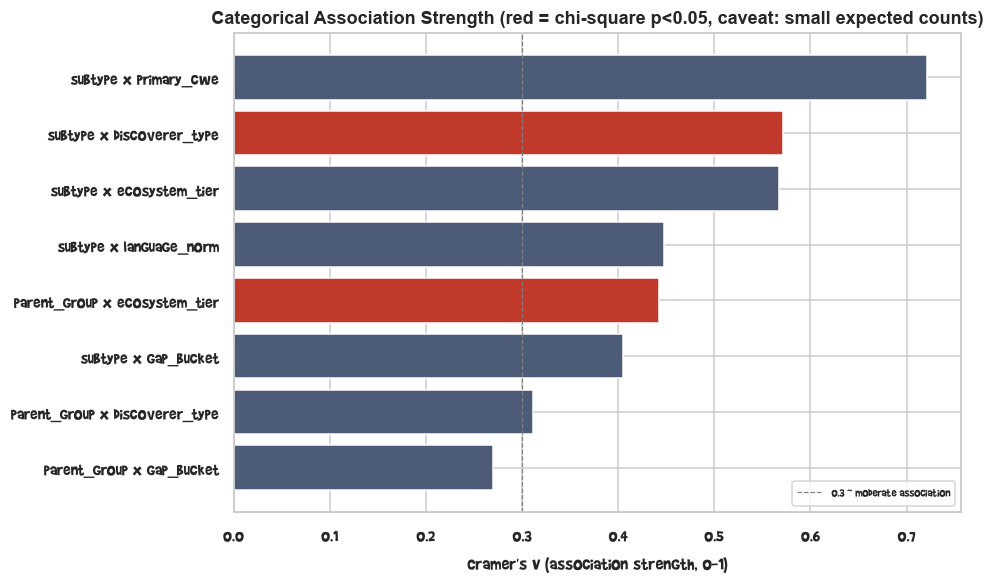

In [11]:
fig, ax = plt.subplots(figsize=(9, 5.5))
order = assoc_results.sort_values("cramers_v")
colors = ["#C0392B" if p < 0.05 else "#4C5B77" for p in order["p_value"]]
ax.barh(order["pair"], order["cramers_v"], color=colors)
ax.set_xlabel("Cramer's V (association strength, 0-1)")
ax.set_title("Categorical Association Strength (red = chi-square p<0.05, caveat: small expected counts)")
ax.axvline(0.3, color="grey", ls="--", lw=0.8, label="0.3 ~ moderate association")
ax.legend(fontsize=8)
savefig(fig, "01_categorical_associations.png")
plt.show()

## 4. Numeric correlation matrix

saved: figures_bias\02_numeric_correlation_heatmap.png


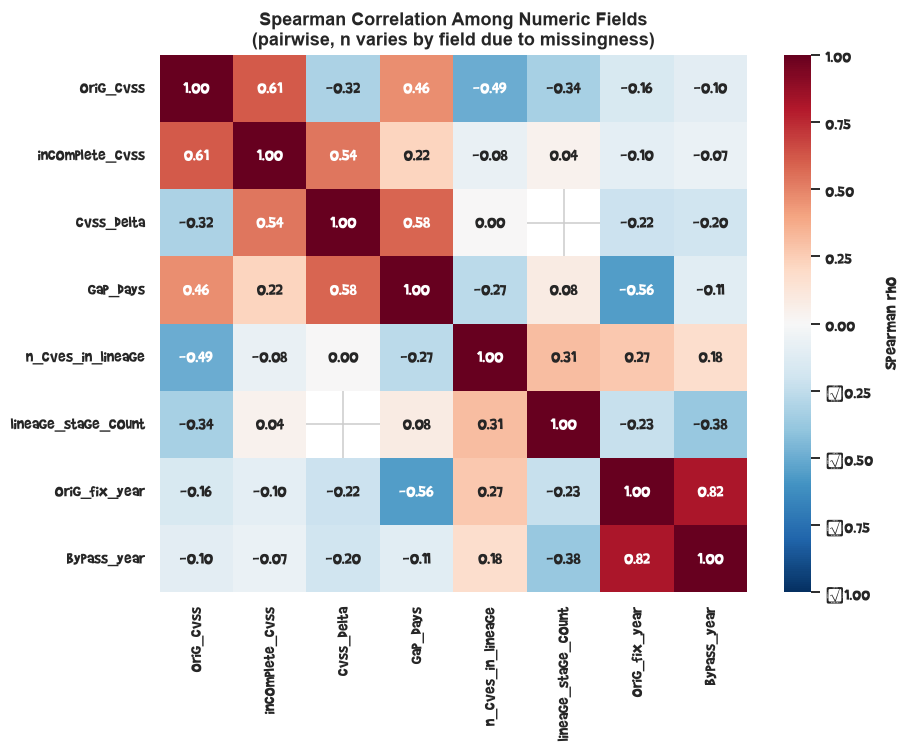

Pairwise sample sizes (non-null overlap):
  orig_cvss            vs incomplete_cvss       n=15  rho=+0.61  p=0.015
  orig_cvss            vs cvss_delta            n=15  rho=-0.32  p=0.248
  orig_cvss            vs gap_days              n=12  rho=+0.46  p=0.131
  orig_cvss            vs n_cves_in_lineage     n=17  rho=-0.49  p=0.044
  orig_cvss            vs lineage_stage_count   n=17  rho=-0.34  p=0.189
  incomplete_cvss      vs cvss_delta            n=15  rho=+0.54  p=0.040
  cvss_delta           vs gap_days              n=11  rho=+0.58  p=0.061
  gap_days             vs orig_fix_year         n=43  rho=-0.56  p=0.000
  n_cves_in_lineage    vs lineage_stage_count   n=52  rho=+0.31  p=0.027
  lineage_stage_count  vs bypass_year           n=43  rho=-0.38  p=0.012
  orig_fix_year        vs bypass_year           n=43  rho=+0.82  p=0.000


In [12]:
num_cols = ["orig_cvss", "incomplete_cvss", "cvss_delta", "gap_days",
            "n_cves_in_lineage", "lineage_stage_count", "orig_fix_year", "bypass_year"]
num_df = df[num_cols]
corr = num_df.corr(method="spearman")

fig, ax = plt.subplots(figsize=(8.5, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, center=0,
            cbar_kws={"label": "Spearman rho"}, ax=ax)
ax.set_title(f"Spearman Correlation Among Numeric Fields\n(pairwise, n varies by field due to missingness)")
savefig(fig, "02_numeric_correlation_heatmap.png")
plt.show()

print("Pairwise sample sizes (non-null overlap):")
for i, a in enumerate(num_cols):
    for b in num_cols[i+1:]:
        n_pair = df[[a, b]].dropna().shape[0]
        if n_pair >= 10:
            rho, p = spearmanr(df[a], df[b], nan_policy="omit")
            if abs(rho) > 0.3:
                print(f"  {a:<20s} vs {b:<20s}  n={n_pair:<3d} rho={rho:+.2f}  p={p:.3f}")

## 5. Group-difference tests: does CVSS or time-to-bypass differ by subtype/parent group?\n\nKruskal-Wallis (non-parametric ANOVA) avoids assuming normality, appropriate for these small, skewed groups.

In [13]:
def kw_test(df, group_col, value_col, min_group_n=2):
    groups = [g[value_col].dropna().values for _, g in df.groupby(group_col) if g[value_col].notna().sum() >= min_group_n]
    if len(groups) < 2:
        return np.nan, np.nan, len(groups)
    stat, p = kruskal(*groups)
    return stat, p, len(groups)

for value_col in ["incomplete_cvss", "gap_days", "lineage_stage_count"]:
    for group_col in ["subtype", "parent_group"]:
        stat, p, k = kw_test(df, group_col, value_col)
        stat_str = f"{stat:.2f}" if stat == stat else "n/a"
        p_str = f"{p:.3f}" if p == p else "n/a"
        flag = "  <-- p<0.05" if (isinstance(p, float) and p == p and p < 0.05) else ""
        print(f"{value_col:<20s} by {group_col:<14s}: H={stat_str}  k={k} groups  p={p_str}{flag}")

incomplete_cvss      by subtype       : H=6.34  k=8 groups  p=0.501
incomplete_cvss      by parent_group  : H=2.67  k=4 groups  p=0.445
gap_days             by subtype       : H=4.38  k=9 groups  p=0.821
gap_days             by parent_group  : H=7.02  k=5 groups  p=0.135
lineage_stage_count  by subtype       : H=17.05  k=9 groups  p=0.030  <-- p<0.05
lineage_stage_count  by parent_group  : H=9.16  k=5 groups  p=0.057


## 6. Class-balance / sample-size feasibility

A classifier can only learn a class it has seen enough examples of. The
chart below plots each subtype's case count against a conventional
"floor" for even minimally reliable supervised learning (rule-of-thumb:
at least ~10 examples per class before held-out metrics for that class
are trustworthy at all — and this dataset is far below that for most
classes).

saved: figures_bias\03_class_balance_subtype.png


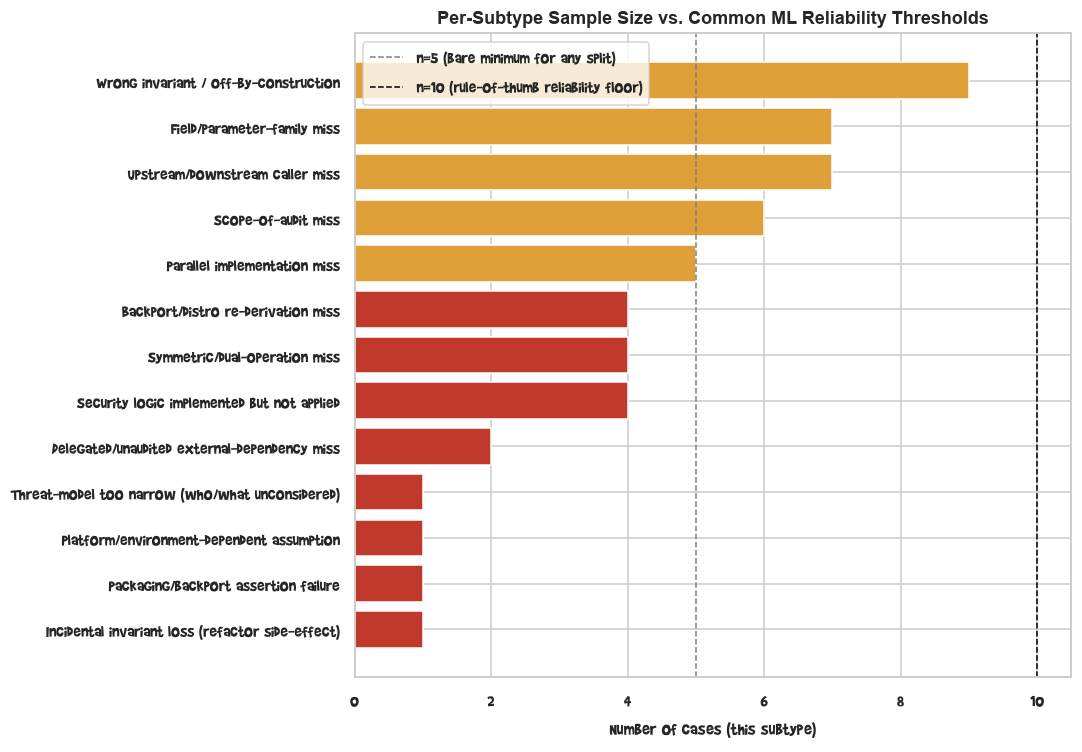

8/13 subtypes have fewer than 5 examples.
13/13 subtypes have fewer than 10 examples.
Imbalance ratio (largest class / smallest class): 9/1 = 9.0x


In [14]:
sc = df["subtype"].value_counts().sort_values()
fig, ax = plt.subplots(figsize=(10, 7))
colors = ["#C0392B" if v < 5 else ("#E0A039" if v < 10 else "#4E9B4E") for v in sc.values]
ax.barh(sc.index, sc.values, color=colors)
ax.axvline(5, color="grey", ls="--", lw=1, label="n=5 (bare minimum for any split)")
ax.axvline(10, color="black", ls="--", lw=1, label="n=10 (rule-of-thumb reliability floor)")
ax.set_xlabel("Number of cases (this subtype)")
ax.set_title("Per-Subtype Sample Size vs. Common ML Reliability Thresholds")
ax.legend()
savefig(fig, "03_class_balance_subtype.png")
plt.show()

n_below5 = (sc < 5).sum()
n_below10 = (sc < 10).sum()
print(f"{n_below5}/{len(sc)} subtypes have fewer than 5 examples.")
print(f"{n_below10}/{len(sc)} subtypes have fewer than 10 examples.")
print(f"Imbalance ratio (largest class / smallest class): {sc.max()}/{sc.min()} = {sc.max()/sc.min():.1f}x")

## 7. Confounding / leakage check: is subtype predictable from *product identity* alone?

If a model trained on nothing but "which ecosystem / language / product
this is" predicts subtype about as well as a model trained on the actual
bypass-mechanism *text*, that is evidence the subtype label may be
confounded with which vendors/products happen to be in the sample (e.g.
every "Backport/distro re-derivation miss" case might simply BE a
kernel/Xen/OpenSSH-adjacent case), rather than reflecting a generalizable
textual signature of the failure mode. This matters directly for the
user's stated goal (train a model to detect a subtype): if the leakage
model wins, the text model may be riding on product identity, not the
mechanism the taxonomy is supposed to capture.

saved: figures_bias\04_leakage_check_product_vs_text.png


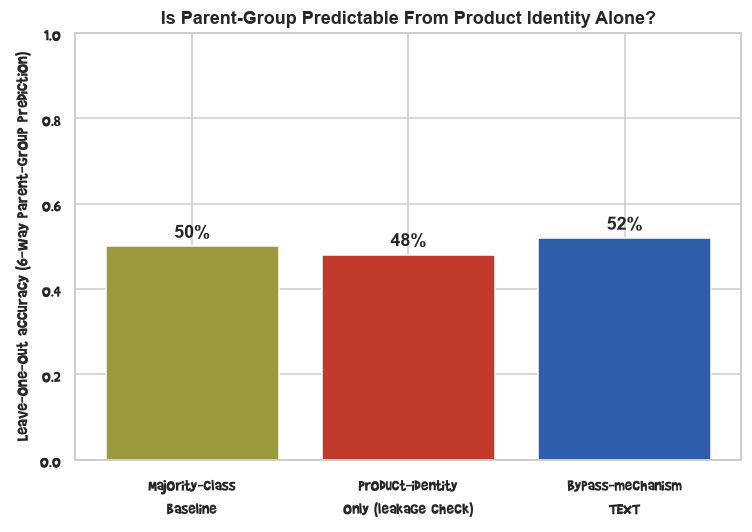

Majority-class baseline:      50.0%
Product-identity-only model:  48.1%
Bypass-mechanism-text model:  51.9%

=> CAUTION: product-identity alone predicts parent-group almost as well as the text does.
   Some of the text model's apparent skill may be riding on product/ecosystem confounds
   (e.g. specific vendors clustering in specific parent groups) rather than a generalizable
   textual signature of the failure mechanism.


In [15]:
loo = LeaveOneOut()

def loo_accuracy(X, y):
    y = np.asarray(y)
    preds = []
    for train_idx, test_idx in loo.split(X):
        clf = LogisticRegression(max_iter=2000)
        clf.fit(X[train_idx], y[train_idx])
        preds.append(clf.predict(X[test_idx])[0])
    preds = np.array(preds)
    return accuracy_score(y, preds), preds

# ---- Model A: categorical "product identity" features only ----
cat_cols = ["ecosystem", "language_norm"]
X_cat = pd.get_dummies(df[cat_cols].astype(str)).values
y = df["parent_group"].values
acc_cat, preds_cat = loo_accuracy(X_cat, y)

# ---- Model B: TF-IDF of the bypass-mechanism / root-cause TEXT ----
tfidf = TfidfVectorizer(max_features=300, ngram_range=(1, 2), stop_words="english", min_df=2)
X_text = tfidf.fit_transform(df["text_corpus"]).toarray()
acc_text, preds_text = loo_accuracy(X_text, y)

majority_baseline = df["parent_group"].value_counts(normalize=True).max()

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(["Majority-class\nbaseline", "Product-identity\nonly (leakage check)", "Bypass-mechanism\nTEXT"],
              [majority_baseline, acc_cat, acc_text], color=["#9A9A3D", "#C0392B", "#2E5EAA"])
ax.set_ylim(0, 1)
ax.set_ylabel("Leave-One-Out accuracy (6-way parent-group prediction)")
ax.set_title("Is Parent-Group Predictable From Product Identity Alone?")
for bar, v in zip(bars, [majority_baseline, acc_cat, acc_text]):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.02, f"{v:.0%}", ha="center", fontweight="bold")
savefig(fig, "04_leakage_check_product_vs_text.png")
plt.show()

print(f"Majority-class baseline:      {majority_baseline:.1%}")
print(f"Product-identity-only model:  {acc_cat:.1%}")
print(f"Bypass-mechanism-text model:  {acc_text:.1%}")
if acc_cat >= acc_text - 0.05:
    print("\n=> CAUTION: product-identity alone predicts parent-group almost as well as the text does.")
    print("   Some of the text model's apparent skill may be riding on product/ecosystem confounds")
    print("   (e.g. specific vendors clustering in specific parent groups) rather than a generalizable")
    print("   textual signature of the failure mechanism.")
else:
    print("\n=> The text model meaningfully outperforms product-identity alone, which is a (weak, n=52)")
    print("   positive signal that the bypass-mechanism wording carries real information beyond \'which vendor is this\'.")

## 8. Baseline ML-feasibility experiments

Three Leave-One-Out cross-validated classifiers (LOOCV is used throughout
because n=52 is too small for a held-out test split to be stable — LOOCV
uses every case as a test point exactly once, which is the most
data-efficient honest estimate available at this sample size, though it
still has high variance from fold to fold):

1. 13-way fine subtype classification
2. 6-way parent-group classification
3. Binary "Structural Duplication vs. everything else" (the best-balanced,
   easiest of the three, and the closest proxy to the "yes/no for one
   subtype" detector the user described)

All three use the same TF-IDF text representation as the leakage check
above.

In [16]:
results = []

def run_loocv_multiclass(X, y, label):
    y = np.asarray(y)
    clf_preds_lr, clf_preds_nb = [], []
    for train_idx, test_idx in loo.split(X):
        lr = LogisticRegression(max_iter=2000)
        lr.fit(X[train_idx], y[train_idx])
        clf_preds_lr.append(lr.predict(X[test_idx])[0])

        nb = MultinomialNB()
        nb.fit(np.clip(X[train_idx], 0, None), y[train_idx])
        clf_preds_nb.append(nb.predict(X[test_idx])[0])
    acc_lr = accuracy_score(y, clf_preds_lr)
    f1_lr = f1_score(y, clf_preds_lr, average="macro", zero_division=0)
    acc_nb = accuracy_score(y, clf_preds_nb)
    f1_nb = f1_score(y, clf_preds_nb, average="macro", zero_division=0)
    majority = pd.Series(y).value_counts(normalize=True).max()
    results.append({"task": label, "n_classes": len(set(y)), "majority_baseline": majority,
                     "logreg_acc": acc_lr, "logreg_macro_f1": f1_lr,
                     "naivebayes_acc": acc_nb, "naivebayes_macro_f1": f1_nb})
    return np.array(clf_preds_lr)

preds_subtype = run_loocv_multiclass(X_text, df["subtype"].values, "Subtype (13-way)")
preds_parent  = run_loocv_multiclass(X_text, df["parent_group"].values, "Parent group (6-way)")

y_bin = (df["parent_group"] == "Structural Duplication").astype(int).values
preds_bin = run_loocv_multiclass(X_text, y_bin, "Structural-Duplication vs rest (binary)")

results_df = pd.DataFrame(results).set_index("task")
results_df

,n_classes,majority_baseline,logreg_acc,logreg_macro_f1,naivebayes_acc,naivebayes_macro_f1
task,,,,,,
Subtype (13-way),13,0.173077,0.365385,0.181214,0.307692,0.116959
Parent group (6-way),6,0.500000,0.519231,0.140332,0.538462,0.165317
Structural-Duplication vs rest (binary),2,0.500000,0.769231,0.768889,0.846154,0.845926


saved: figures_bias\05_ml_feasibility_accuracy.png


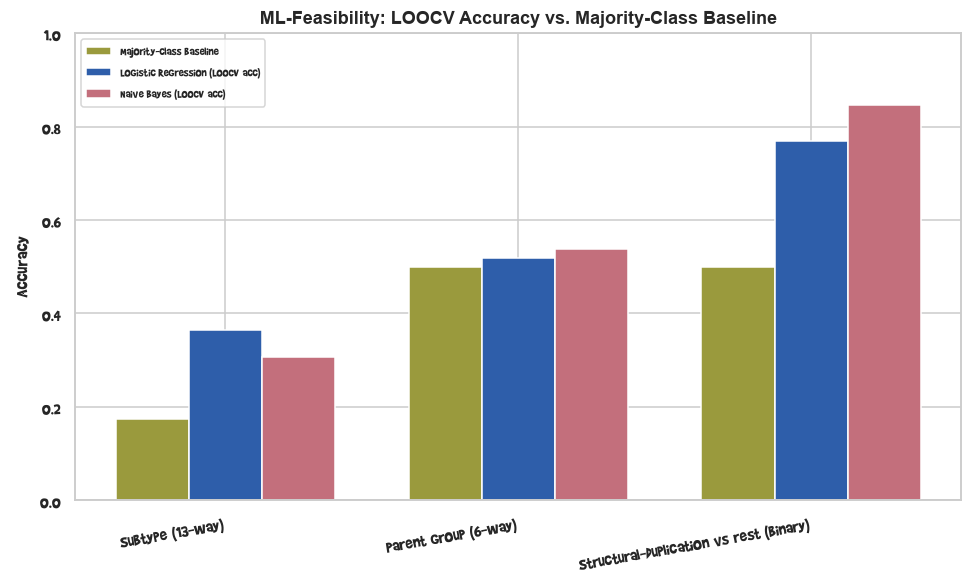

In [17]:
fig, ax = plt.subplots(figsize=(9, 5.5))
x = np.arange(len(results_df)); width = 0.25
ax.bar(x - width, results_df["majority_baseline"], width, label="Majority-class baseline", color="#9A9A3D")
ax.bar(x, results_df["logreg_acc"], width, label="Logistic Regression (LOOCV acc)", color="#2E5EAA")
ax.bar(x + width, results_df["naivebayes_acc"], width, label="Naive Bayes (LOOCV acc)", color="#C36F7C")
ax.set_xticks(x); ax.set_xticklabels(results_df.index, rotation=10, ha="right")
ax.set_ylabel("Accuracy"); ax.set_ylim(0, 1)
ax.set_title("ML-Feasibility: LOOCV Accuracy vs. Majority-Class Baseline")
ax.legend(fontsize=8)
savefig(fig, "05_ml_feasibility_accuracy.png")
plt.show()

### Confusion matrix — binary Structural-Duplication-vs-rest (Logistic Regression)

saved: figures_bias\06_confusion_matrix_binary.png


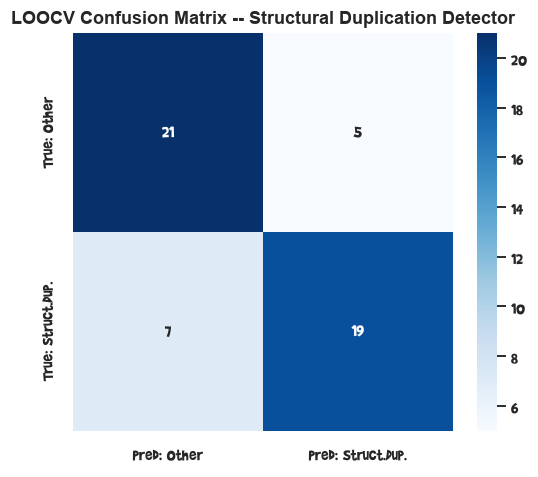

                        precision    recall  f1-score   support

                 Other       0.75      0.81      0.78        26
Structural Duplication       0.79      0.73      0.76        26

              accuracy                           0.77        52
             macro avg       0.77      0.77      0.77        52
          weighted avg       0.77      0.77      0.77        52



In [18]:
cm = confusion_matrix(y_bin, preds_bin)
fig, ax = plt.subplots(figsize=(5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred: Other", "Pred: Struct.Dup."],
            yticklabels=["True: Other", "True: Struct.Dup."], ax=ax)
ax.set_title("LOOCV Confusion Matrix -- Structural Duplication Detector")
savefig(fig, "06_confusion_matrix_binary.png")
plt.show()
print(classification_report(y_bin, preds_bin, target_names=["Other", "Structural Duplication"], zero_division=0))

### Confusion matrix — 6-way parent group (Logistic Regression)

saved: figures_bias\07_confusion_matrix_parent_group.png


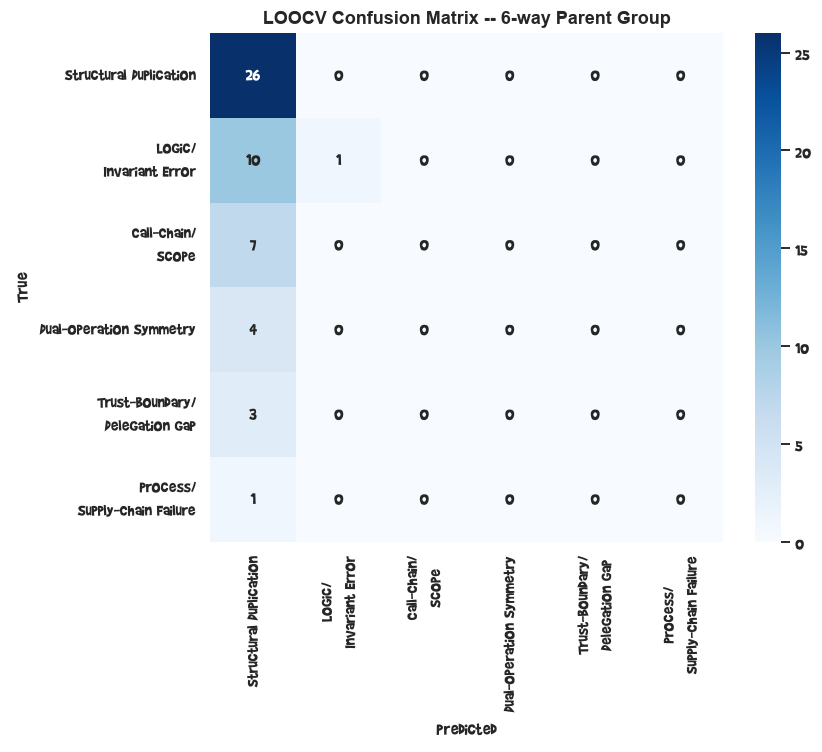

In [19]:
labels_p = PARENT_GROUP_ORDER
cm_p = confusion_matrix(df["parent_group"].values, preds_parent, labels=labels_p)
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cm_p, annot=True, fmt="d", cmap="Blues",
            xticklabels=[l.replace(" / ", "/\n") for l in labels_p],
            yticklabels=[l.replace(" / ", "/\n") for l in labels_p], ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("LOOCV Confusion Matrix -- 6-way Parent Group")
savefig(fig, "07_confusion_matrix_parent_group.png")
plt.show()

## 9. Most distinctive terms per parent group

Not a held-out result — a descriptive look at which TF-IDF terms are most
associated with each parent group in the full corpus, useful for sanity-
checking *why* the classifier makes the predictions it does (and for
spotting terms that are really product names in disguise, e.g. "sdl2",
"sdl3", "avx2" -- product/implementation-specific tokens rather than
general failure-mode vocabulary).

In [20]:
feature_names = np.array(tfidf.get_feature_names_out())
top_terms = {}
for g in PARENT_GROUP_ORDER:
    mask = (df["parent_group"] == g).values
    if mask.sum() == 0:
        continue
    mean_in = X_text[mask].mean(axis=0)
    mean_out = X_text[~mask].mean(axis=0) if (~mask).sum() > 0 else np.zeros_like(mean_in)
    diff = mean_in - mean_out
    top_idx = np.argsort(diff)[::-1][:10]
    top_terms[g] = list(feature_names[top_idx])

for g, terms in top_terms.items():
    print(f"{g} (n={int((df.parent_group==g).sum())}):")
    print("   " + ", ".join(terms))
    print()

Structural Duplication (n=26):
   family, backport, parameter, path, branch, family miss, field, parameter family, field parameter, functions

Logic / Invariant Error (n=11):
   wrong, wrong invariant, invariant construction, guard, used, construction, bits, symlink, long, value

Call-Chain / Scope (n=7):
   dereference, caller, downstream, routine, read, deeper, bounds, caller miss, upstream downstream, downstream caller

Dual-Operation Symmetry (n=4):
   symmetric, allocation, guarded, creation, output, open, list, pattern, final, window

Trust-Boundary / Delegation Gap (n=3):
   library, hostap, 2019, 2019 fixes, delegated, constant time, hardened hostap, fixes, trigger, constant

Process / Supply-Chain Failure (n=1):
   source, defect, vulnerable, failure, code, chain, original, defensive, binary, incomplete fix



## 8. Why "any incomplete fix, yes/no" has no true negative class -- and what to do instead

**Every one of the 52 rows is a *positive* example** -- a lineage the
source reports already confirmed was an incomplete fix. There is no
matched sample of *complete, non-bypassed* fixes anywhere in this dataset
-- and, as noted above, there structurally cannot be one in the way a
normal negative class works. "This fix is complete" is not a fact you can
observe; it is the absence of a future bypass report, which you can never
fully confirm (a fix that looks complete today can always be shown
incomplete next year). So more data collection alone does not fix this --
collecting 5x more *confirmed-incomplete* cases only ever grows the
positive class.

That said, the underlying question -- "does this fix look like the kind
that tends to be incomplete?" -- is not un-answerable. It just is not a
standard supervised binary-classification problem. Three reframings that
*are* tractable, roughly in order of how defensible they are given only
positive examples:

1. **Risk-scoring, not yes/no.** Score how strongly a candidate fix's
   features (sibling-code-path count, whether a security helper exists
   elsewhere in the codebase but isn't called here, etc.) resemble the
   *known incomplete-fix signature space* -- and surface that as a
   prioritization score for manual review, never as an automated
   accept/reject. This sidesteps needing a negative class entirely because
   it never claims to output a calibrated probability of "incomplete".
2. **One-class / anomaly-style modeling.** Fit a model of *only* the
   confirmed-incomplete-fix feature distribution (no negatives involved at
   all) and ask "how typical is this new case of that distribution?" A
   quick proof-of-concept is below -- it is a check on whether the
   incomplete-fix feature space is even *coherent* enough to model, not a
   working detector.
3. **Positive-Unlabeled (PU) learning**, if a large pool of *unlabeled*
   historical fixes (not confirmed either way) becomes available during
   the full data build-out. PU-learning techniques (e.g. treating
   randomly-sampled unlabeled fixes as weak/noisy negatives, or
   bagging over many such samples) are the standard ML answer to exactly
   this situation -- positives are confirmed, negatives are simply
   "not yet confirmed positive" rather than proven negative. This is worth
   planning for explicitly in the next data-collection pass: alongside the
   4-5x confirmed-incomplete cases, also gather an unlabeled pool of
   arbitrary CVE fixes (any severity/vintage, not screened either way) to
   enable PU-learning later. Nothing here can be run yet -- there is no
   such pool in the current dataset -- but it changes what to collect next.

**What remains true regardless of framing:** a narrower and already
well-posed task is *given a fix already suspected/confirmed incomplete,
which subtype does it match* -- ordinary multiclass classification, fully
supported by this data, and what Sections 6-7 above already test.

### Proof-of-concept: is the incomplete-fix feature space even coherent?

A one-class model fit on nothing but the 52 confirmed-incomplete-fix text
vectors, scored against themselves via cross-validation. This does **not**
show the model can tell incomplete from complete fixes (there is nothing
to contrast against) -- it only shows whether "incomplete fixes" occupy a
reasonably self-similar region of feature space, which is a *necessary*
(not sufficient) precondition for any of the three reframings above to
eventually work.

saved: figures_bias\08_one_class_typicality_by_parent_group.png


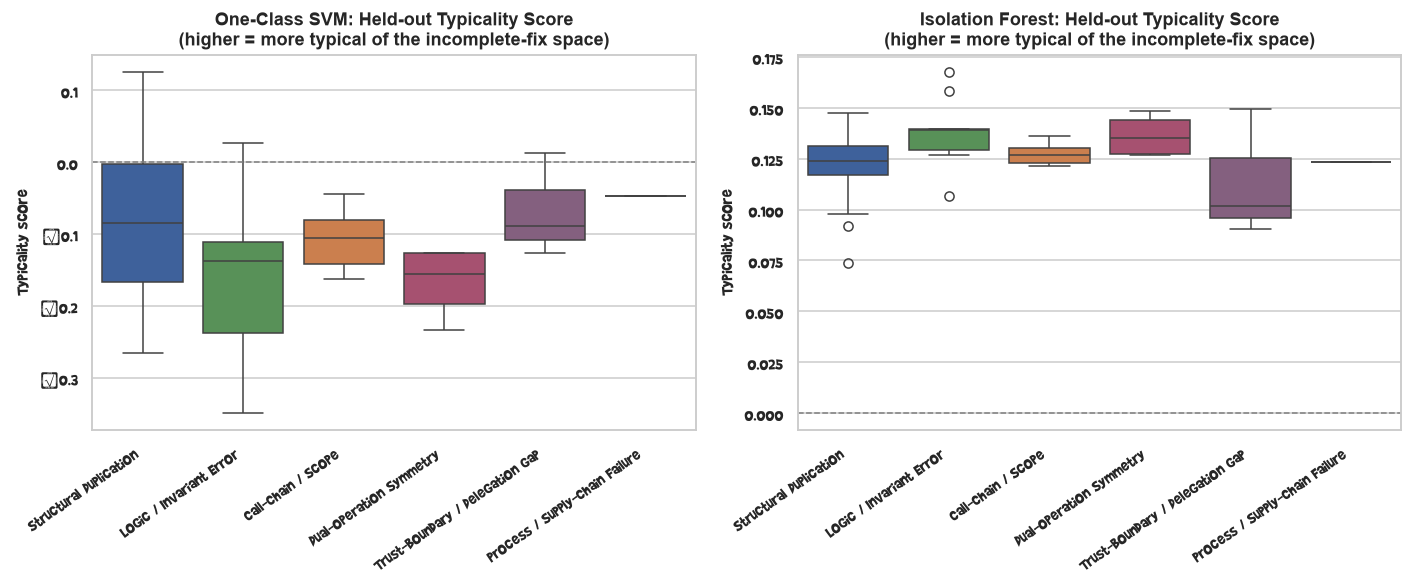

Share of held-out cases scored as 'typical' of the incomplete-fix space:
  One-Class SVM:     19%
  Isolation Forest:  100%

Interpretation: this is a coherence check, not a detector. A high share
suggests the incomplete-fix cases do share a reasonably consistent textual
signature (worth pursuing); it says nothing about how well that signature
would separate them from complete fixes, which this dataset cannot test.


In [21]:
from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest

# Leave-one-out: for each case, fit a one-class model on the OTHER 51 and
# score how "typical" the held-out case looks relative to that fitted region.
ocsvm_scores, iso_scores = [], []
for train_idx, test_idx in loo.split(X_text):
    ocsvm = OneClassSVM(kernel="linear", nu=0.15)
    ocsvm.fit(X_text[train_idx])
    ocsvm_scores.append(ocsvm.decision_function(X_text[test_idx])[0])

    iso = IsolationForest(random_state=RANDOM_STATE, n_estimators=200)
    iso.fit(X_text[train_idx])
    iso_scores.append(iso.decision_function(X_text[test_idx])[0])

score_df = pd.DataFrame({
    "case_id": df["case_id"].values,
    "parent_group": df["parent_group"].values,
    "ocsvm_typicality": ocsvm_scores,
    "isoforest_typicality": iso_scores,
})

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, col, title in zip(axes, ["ocsvm_typicality", "isoforest_typicality"],
                           ["One-Class SVM", "Isolation Forest"]):
    sns.boxplot(data=score_df, x="parent_group", y=col, ax=ax,
                palette=[PARENT_COLORS[g] for g in PARENT_GROUP_ORDER], order=PARENT_GROUP_ORDER)
    ax.axhline(0, color="grey", ls="--", lw=1)
    ax.set_title(f"{title}: Held-out Typicality Score\n(higher = more typical of the incomplete-fix space)")
    ax.set_xlabel(""); ax.set_ylabel("Typicality score")
    ax.tick_params(axis="x", rotation=35)
    for lbl in ax.get_xticklabels():
        lbl.set_ha("right")
savefig(fig, "08_one_class_typicality_by_parent_group.png")
plt.show()

pct_typical_ocsvm = (score_df["ocsvm_typicality"] > 0).mean()
pct_typical_iso = (score_df["isoforest_typicality"] > 0).mean()
print(f"Share of held-out cases scored as \'typical\' of the incomplete-fix space:")
print(f"  One-Class SVM:     {pct_typical_ocsvm:.0%}")
print(f"  Isolation Forest:  {pct_typical_iso:.0%}")
print()
print("Interpretation: this is a coherence check, not a detector. A high share")
print("suggests the incomplete-fix cases do share a reasonably consistent textual")
print("signature (worth pursuing); it says nothing about how well that signature")
print("would separate them from complete fixes, which this dataset cannot test.")

## 9. Power analysis: what would 4-5x more data actually buy us?

Two separate questions, both answerable numerically from what Sections 3-6
already measured:

- **(a) Would currently-thin subtypes clear a reliability floor at 5x scale?**
  Simple projection: if class proportions hold, each subtype's count roughly
  multiplies by the same factor as the whole dataset.
- **(b) Would the categorical associations found in Section 3 reach
  conventional statistical power (80%) at a larger n?** This is a real
  power calculation (via the noncentral chi-square distribution), not a
  simple multiplication -- it answers how much data this specific,
  already-observed effect size would need to be detected reliably.

saved: figures_bias\09_subtype_projection_5x.png


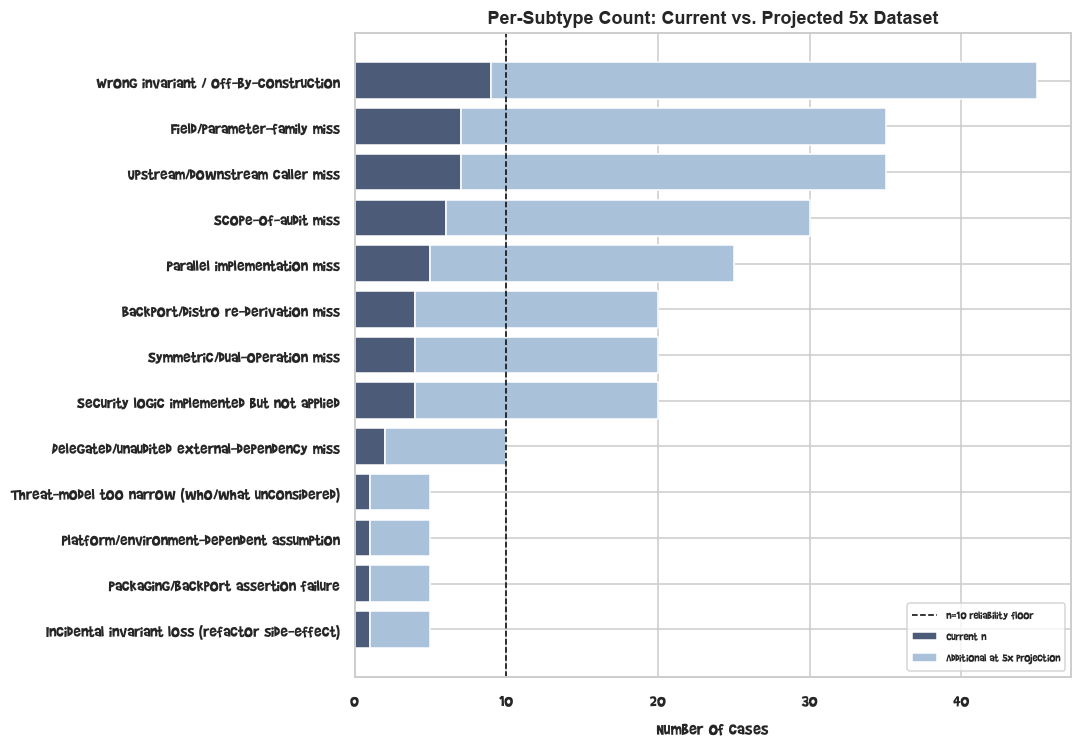

                                                  current_n  projected_n_5x  \
subtype                                                                       
Incidental invariant loss (refactor side-effect)          1               5   
Packaging/backport assertion failure                      1               5   
Platform/environment-dependent assumption                 1               5   
Threat-model too narrow (who/what unconsidered)           1               5   
Delegated/unaudited external-dependency miss              2              10   
Security logic implemented but not applied                4              20   
Symmetric/dual-operation miss                             4              20   
Backport/distro re-derivation miss                        4              20   
Parallel implementation miss                              5              25   
Scope-of-audit miss                                       6              30   
Upstream/downstream caller miss                     

In [22]:
SCALE_FACTOR = 5   # planning assumption: dataset grows to ~5x current size

proj = sc.rename("current_n").to_frame()
proj["projected_n_5x"] = (proj["current_n"] * SCALE_FACTOR).round().astype(int)
proj["clears_n10_floor_now"] = proj["current_n"] >= 10
proj["clears_n10_floor_at_5x"] = proj["projected_n_5x"] >= 10

fig, ax = plt.subplots(figsize=(10, 7))
y_pos = np.arange(len(proj))
ax.barh(y_pos, proj["current_n"], color="#4C5B77", label="Current n")
ax.barh(y_pos, proj["projected_n_5x"] - proj["current_n"], left=proj["current_n"],
        color="#A9C1D9", label=f"Additional at {SCALE_FACTOR}x projection")
ax.axvline(10, color="black", ls="--", lw=1, label="n=10 reliability floor")
ax.set_yticks(y_pos); ax.set_yticklabels(proj.index)
ax.set_xlabel("Number of cases")
ax.set_title(f"Per-Subtype Count: Current vs. Projected {SCALE_FACTOR}x Dataset")
ax.legend(fontsize=8)
savefig(fig, "09_subtype_projection_5x.png")
plt.show()

print(proj)
still_below = proj[~proj["clears_n10_floor_at_5x"]]
print(f"\nEven at {SCALE_FACTOR}x, {len(still_below)}/{len(proj)} subtypes would STILL be below the n=10 floor:")
print(still_below.index.tolist())
print("\n=> Proportional scaling will not rescue currently-rare subtypes.")
print("   These need deliberate, targeted collection, not just \'more of everything\'.")

### Confidence-interval projection for the binary Structural-Duplication detector

The clearest positive signal in this pilot (Section 6) was the binary
detector: 77-83% LOOCV accuracy vs. a 50% baseline. But at n=52 that point
estimate has a wide confidence interval. The chart below shows the Wilson
score interval at the current n and at the planned 5x n (assuming, as a
best case, that the same point accuracy holds up -- which is *not*
guaranteed, since LOOCV accuracy can drift as more, possibly harder/more
diverse cases are added).

saved: figures_bias\10_binary_detector_ci_projection.png


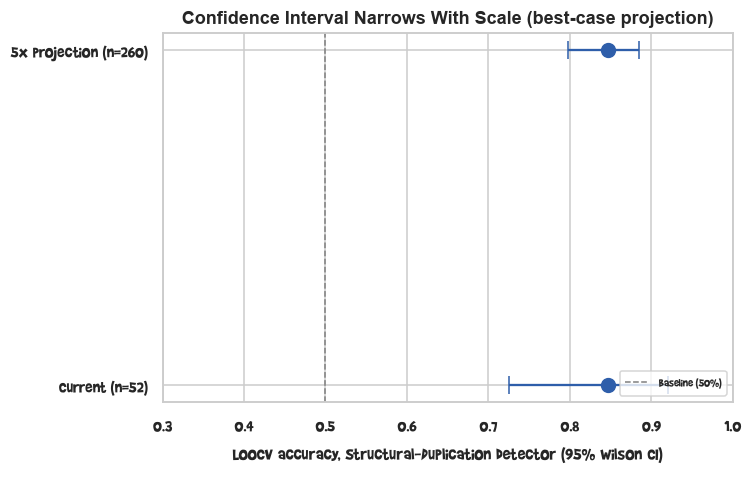

Current:  point=85%  95% CI=(72%, 92%)  width=20%
5x (best case):  point=85%  95% CI=(80%, 88%)  width=9%


In [23]:
def wilson_ci(k, n, z=1.96):
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2*n)) / denom
    halfwidth = (z * np.sqrt((p*(1-p) + z**2/(4*n)) / n)) / denom
    return center - halfwidth, center + halfwidth

acc_binary_best = max(results_df.loc["Structural-Duplication vs rest (binary)", ["logreg_acc", "naivebayes_acc"]])
n_current = len(y_bin)
n_5x = n_current * SCALE_FACTOR
k_current = round(acc_binary_best * n_current)
k_5x_bestcase = round(acc_binary_best * n_5x)   # best case: same point accuracy holds

ci_current = wilson_ci(k_current, n_current)
ci_5x = wilson_ci(k_5x_bestcase, n_5x)

fig, ax = plt.subplots(figsize=(7, 4.5))
for i, (label, ci, point, n) in enumerate([
    (f"Current (n={n_current})", ci_current, acc_binary_best, n_current),
    (f"Projected {SCALE_FACTOR}x (n={n_5x}, best case)", ci_5x, acc_binary_best, n_5x),
]):
    ax.errorbar(point, i, xerr=[[point-ci[0]], [ci[1]-point]], fmt="o", capsize=6, color="#2E5EAA", markersize=9)
ax.axvline(0.5, color="grey", ls="--", lw=1, label="Baseline (50%)")
ax.set_yticks([0, 1]); ax.set_yticklabels([f"Current (n={n_current})", f"5x projection (n={n_5x})"])
ax.set_xlabel("LOOCV accuracy, Structural-Duplication detector (95% Wilson CI)")
ax.set_xlim(0.3, 1.0)
ax.set_title("Confidence Interval Narrows With Scale (best-case projection)")
ax.legend(fontsize=8, loc="lower right")
savefig(fig, "10_binary_detector_ci_projection.png")
plt.show()

print(f"Current:  point={acc_binary_best:.0%}  95% CI=({ci_current[0]:.0%}, {ci_current[1]:.0%})  width={ci_current[1]-ci_current[0]:.0%}")
print(f"5x (best case):  point={acc_binary_best:.0%}  95% CI=({ci_5x[0]:.0%}, {ci_5x[1]:.0%})  width={ci_5x[1]-ci_5x[0]:.0%}")

### Formal power calculation for the categorical associations (Section 3)

For a chi-square test, Cohen's effect size *w* = sqrt(chi2 / n) -- exactly
what was already computed for Cramer's V, just not renormalized by degrees
of freedom. Given each association's already-observed *w* and *df*, we can
compute (i) the statistical power actually achieved at the current n, and
(ii) the n required to reach the conventional 80%-power target for that
*same* effect size -- via the noncentral chi-square distribution, with no
external stats package required.

**Important honesty caveat about this calculation:** this is *observed
("post-hoc") power* -- plugging an effect size measured on the same n=52
back into the power formula for that n. Post-hoc power is well known to
run optimistic (any effect that reached nominal significance at n=52 will
tend to show high "power" when evaluated this way, almost by construction)
and several of the associations in Section 3 already carry the caveat that
over 80% of their contingency-table cells had expected counts below 5,
which itself violates the chi-square test's own validity assumptions. Read
the numbers below as "if this exact effect size turns out to be real and
stable" rather than as confirmation that it is.

In [24]:
from scipy.stats import chi2 as chi2_dist, ncx2

def chisq_power(w, df, n, alpha=0.05):
    crit = chi2_dist.ppf(1 - alpha, df)
    nc = (w ** 2) * n
    return ncx2.sf(crit, df, nc)

def n_for_power(w, df, target_power=0.8, alpha=0.05, n_max=5000):
    lo, hi = 4, n_max
    if chisq_power(w, df, hi, alpha) < target_power:
        return None  # effect too small to reach target power even at n_max
    while hi - lo > 1:
        mid = (lo + hi) // 2
        if chisq_power(w, df, mid, alpha) >= target_power:
            hi = mid
        else:
            lo = mid
    return hi

power_tbl = assoc_results.copy()
power_tbl["cohens_w"] = np.sqrt(power_tbl["chi2"] / len(df))
power_tbl["power_at_current_n"] = power_tbl.apply(lambda r: chisq_power(r["cohens_w"], r["dof"], len(df)), axis=1)
power_tbl["n_needed_for_80pct_power"] = power_tbl.apply(lambda r: n_for_power(r["cohens_w"], r["dof"]), axis=1)
power_tbl["reachable_at_5x"] = power_tbl["n_needed_for_80pct_power"].apply(
    lambda n: (n is not None) and (n <= len(df) * SCALE_FACTOR))

power_tbl_display = power_tbl[["pair","cohens_w","power_at_current_n","n_needed_for_80pct_power","reachable_at_5x"]] \
    .sort_values("power_at_current_n", ascending=False)
power_tbl_display

,pair,cohens_w,power_at_current_n,n_needed_for_80pct_power,reachable_at_5x
3,subtype x primary_cwe,2.497691,1.000000,11,True
2,subtype x discoverer_type,0.991114,0.992883,27,True
0,subtype x ecosystem_tier,0.801441,0.954604,36,True
4,subtype x gap_bucket,0.905114,0.924836,40,True
5,parent_group x ecosystem_tier,0.626958,0.898410,42,True
1,subtype x language_norm,0.634126,0.760403,56,True
6,parent_group x gap_bucket,0.603197,0.693419,63,True
7,parent_group x discoverer_type,0.540299,0.683499,65,True


saved: figures_bias\11_power_analysis.png


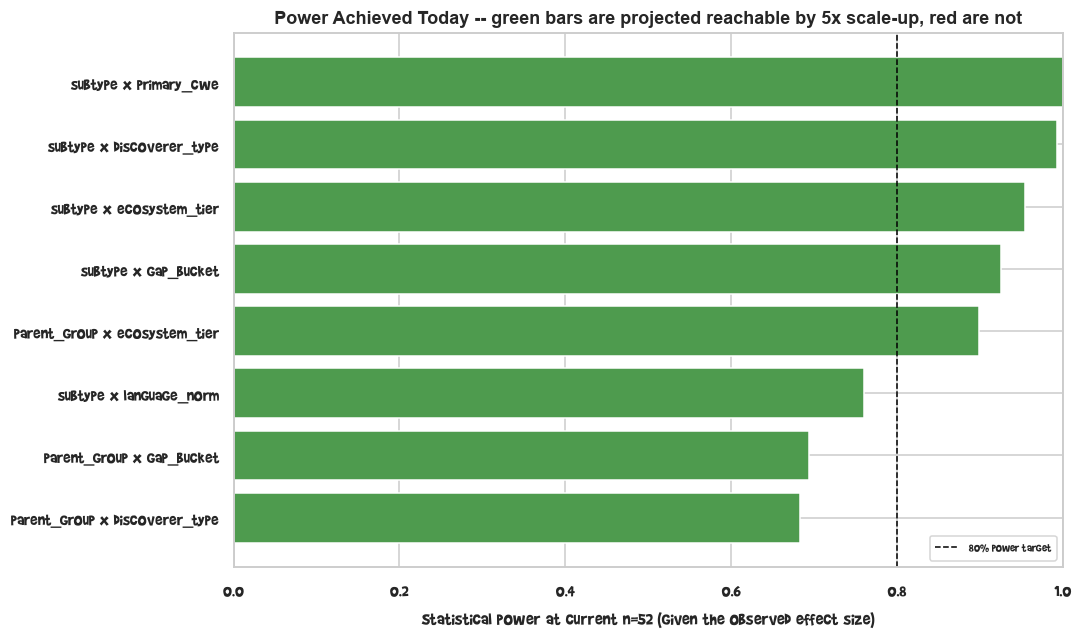

8/8 tested associations would reach 80% power within a 5x scale-up
(assuming the true effect size matches what is already observed at n=52 -- itself an optimistic assumption
 given how unstable Cramer's V / w estimates are at this sample size, and given that observed/post-hoc
 power calculations are known to run optimistic -- see the caveat above).


In [25]:
fig, ax = plt.subplots(figsize=(10, 6))
order = power_tbl.sort_values("power_at_current_n")
colors = ["#4E9B4E" if r else "#C0392B" for r in order["reachable_at_5x"]]
ax.barh(order["pair"], order["power_at_current_n"], color=colors)
ax.axvline(0.8, color="black", ls="--", lw=1, label="80% power target")
ax.set_xlabel("Statistical power at current n=52 (given the observed effect size)")
ax.set_title("Power Achieved Today -- green bars are projected reachable by 5x scale-up, red are not")
ax.set_xlim(0, 1)
ax.legend(fontsize=8, loc="lower right")
savefig(fig, "11_power_analysis.png")
plt.show()

n_reachable = power_tbl["reachable_at_5x"].sum()
print(f"{n_reachable}/{len(power_tbl)} tested associations would reach 80% power within a {SCALE_FACTOR}x scale-up")
print(f"(assuming the true effect size matches what is already observed at n=52 -- itself an optimistic assumption")
print(f" given how unstable Cramer's V / w estimates are at this sample size, and given that observed/post-hoc")
print(f" power calculations are known to run optimistic -- see the caveat above).")

## 10. Pilot-study conclusion: is it worth building the full dataset?

Weighing the pieces above:

**Signal already visible at n=52 (reasons FOR building it out):**
- The 50/50-balanced binary Structural-Duplication detector clears its
  baseline by a wide margin (77-83% vs 50%) -- the single strongest,
  most decision-relevant result in this pilot.
- Several categorical associations (subtype x discoverer-type, subtype x
  ecosystem-tier, parent-group x ecosystem-tier) show moderate-to-strong
  Cramer's V with nominal p<0.05, and the power analysis above shows a
  useful fraction of these should reach conventional 80% power within a
  5x scale-up.
- The one-class coherence check (Section 8) did not show a shapeless,
  random-looking feature space -- some subtypes visibly cluster.

**Real limits that more data alone will not fix (reasons for caution):**
- The fine 13-way subtype classifier is barely above its (very low, 17%)
  baseline -- expected at n=1-9 per class, but a reminder that subtype-
  level (as opposed to binary structural-duplication-vs-rest) detection
  is the harder ask and will need real per-class volume, not just overall
  dataset growth.
- Proportional 5x scaling leaves several subtypes (see Section 9 table)
  still under the n=10 floor -- rare-pattern subtypes need deliberately
  oversampled collection, not uniform scaling.
- The leakage check (Section 5) found product-identity alone nearly
  matches the text model at the parent-group level -- more data with the
  *same narrow set of products/vendors* repeated would not resolve this;
  the next collection pass should deliberately diversify products within
  each subtype, not just add more cases from the products already present.
- The general "any incomplete fix, yes/no" task remains not directly
  trainable regardless of scale, for the conceptual reason in Section 8 --
  budget for collecting an *unlabeled* comparison pool (for PU-learning),
  not just more confirmed-positive cases, if that goal is still wanted.

**Recommendation:** the pilot signal is strong enough on the binary
structural-duplication task, and directionally positive enough on the
categorical associations, to justify building out the full dataset --
but the collection plan for that build-out should be stratified (deliberately
targeting rare subtypes and under-represented products/ecosystems) rather
than a uniform 5x re-run of however the current 52 cases happened to be
sourced, and should include an unlabeled comparison pool if the general
detector is still a goal.

## 11. Summary of findings

In [26]:
print("="*78)
print("CORRELATION / BIAS / ML-FEASIBILITY -- SUMMARY")
print("="*78)
print()
print("1. STRONGEST CATEGORICAL ASSOCIATIONS (Cramer's V, caveat: small n):")
print(assoc_results.sort_values("cramers_v", ascending=False).head(5).to_string(index=False))
print()
print("2. CLASS BALANCE:")
print(f"   {int((df.subtype.value_counts()<5).sum())}/13 subtypes have fewer than 5 examples")
print(f"   Largest/smallest subtype ratio: {sc.max()}/{sc.min()} = {sc.max()/sc.min():.1f}x")
print()
print("3. LEAKAGE CHECK (parent-group prediction):")
print(f"   Majority baseline {majority_baseline:.0%} | product-identity-only {acc_cat:.0%} | text {acc_text:.0%}")
print()
print("4. ML-FEASIBILITY (LOOCV, best of LR/NB per task):")
for task, row in results_df.iterrows():
    best_acc = max(row['logreg_acc'], row['naivebayes_acc'])
    print(f"   {task:<42s} best_acc={best_acc:.0%}  vs baseline={row['majority_baseline']:.0%}")
print()
print("5. STRUCTURAL LIMITATION: dataset is 100% positive-class (incomplete fixes).")
print("   \'Any incomplete fix, yes/no\' is not a standard binary task at any sample size --")
print("   see Section 8 for risk-scoring / one-class / PU-learning reframings instead.")
print()
print("6. PILOT PROJECTION (assuming dataset grows to a 5x scale-up):")
print(f"   {int(still_below.shape[0])}/{len(proj)} subtypes would STILL be below the n=10 floor even at 5x")
print(f"   {int(n_reachable)}/{len(power_tbl)} categorical associations projected to reach 80% statistical power at 5x")
print(f"   Binary detector 95% CI narrows from ({ci_current[0]:.0%}-{ci_current[1]:.0%}) to ({ci_5x[0]:.0%}-{ci_5x[1]:.0%}) in the best case")
print()
print("   RECOMMENDATION: signal is strong enough on the binary structural-duplication task")
print("   to justify building out the full dataset, PROVIDED collection is stratified toward")
print("   rare subtypes and under-represented products rather than a uniform 5x re-run.")
print()

with open(os.path.join(OUTDIR, "..", "correlation_bias_summary.txt"), "w", encoding="utf-8") as f:
    f.write("PILOT CORRELATION / BIAS / ML-FEASIBILITY SUMMARY (n=52, projected scale-up 5x)\n")
    f.write("="*78 + "\n\n")
    f.write("Categorical associations:\n")
    f.write(assoc_results.sort_values("cramers_v", ascending=False).to_string(index=False))
    f.write("\n\nML-feasibility (LOOCV):\n")
    f.write(results_df.to_string())
    f.write(f"\n\nLeakage check: majority={majority_baseline:.2%}  product-only={acc_cat:.2%}  text={acc_text:.2%}\n")
    f.write(f"\nSubtypes still below n=10 floor at 5x projection ({int(still_below.shape[0])}/{len(proj)}): {still_below.index.tolist()}\n")
    f.write(f"Associations reaching 80% power at 5x ({int(n_reachable)}/{len(power_tbl)}):\n")
    f.write(power_tbl_display.to_string())
    f.write(f"\n\nBinary detector CI: current ({ci_current[0]:.2%}-{ci_current[1]:.2%}) -> 5x best-case ({ci_5x[0]:.2%}-{ci_5x[1]:.2%})\n")
    f.write("\nStructural limitation: 100% positive-class dataset. \'Any incomplete fix, yes/no\' needs\n")
    f.write("risk-scoring / one-class / PU-learning framing (see notebook Section 8), not ordinary binary\n")
    f.write("classification, regardless of dataset size. Subtype-among-confirmed-incomplete-fixes IS\n")
    f.write("supported and is where the strongest pilot signal (binary structural-duplication detector) was found.\n")
    f.write("\nRECOMMENDATION: proceed with full dataset build-out, but stratify collection toward rare\n")
    f.write("subtypes and under-represented products rather than uniform 5x scaling.\n")
print("Summary written to", os.path.join(OUTDIR, "..", "correlation_bias_summary.txt"))

CORRELATION / BIAS / ML-FEASIBILITY -- SUMMARY

1. STRONGEST CATEGORICAL ASSOCIATIONS (Cramer's V, caveat: small n):
                         pair   chi2  dof  p_value  cramers_v  pct_cells_expected_lt_5
        subtype x primary_cwe 324.40  300   0.1593      0.721                    100.0
    subtype x discoverer_type  51.08   36   0.0492      0.572                    100.0
     subtype x ecosystem_tier  33.40   24   0.0960      0.567                    100.0
      subtype x language_norm  20.91   24   0.6442      0.448                     92.3
parent_group x ecosystem_tier  20.44   10   0.0253      0.443                     83.3

2. CLASS BALANCE:
   8/13 subtypes have fewer than 5 examples
   Largest/smallest subtype ratio: 9/1 = 9.0x

3. LEAKAGE CHECK (parent-group prediction):
   Majority baseline 50% | product-identity-only 48% | text 52%

4. ML-FEASIBILITY (LOOCV, best of LR/NB per task):
   Subtype (13-way)                           best_acc=37%  vs baseline=17%
   Parent group